## verify txt file labels

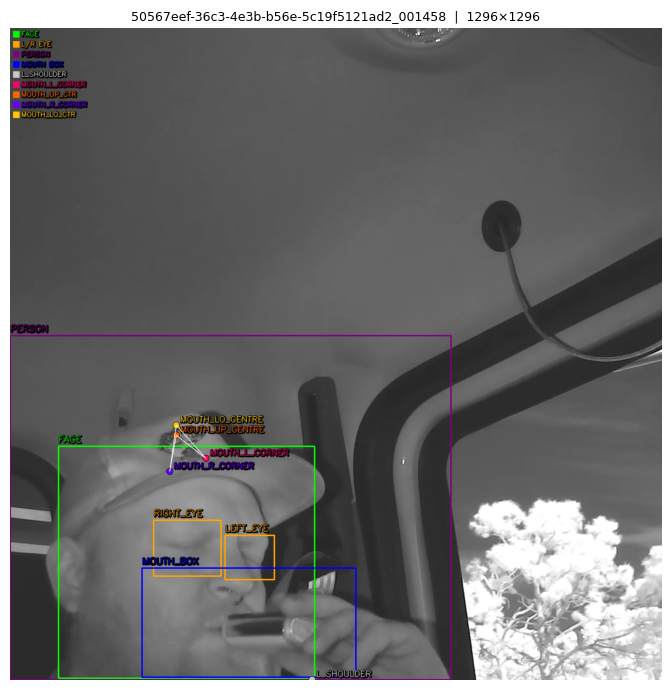

In [32]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ── PATHS ─────────────────────────────────────────────────────────────────────
IMG_DIR = "/inwdata2a/sudhanshu/mouth_keypoints/mouth_frames_dms"
LBL_DIR = "/inwdata2a/sudhanshu/mouth_keypoints/frame_labels/all_frames"

# ── CONTROL ───────────────────────────────────────────────────────────────────
NUM_SAMPLES = 1
RANDOM_SEED = None

# ── CORRECTED LABEL STRUCTURE ─────────────────────────────────────────────────
# [0]      class
# [1:5]    face box            (xc, yc, w, h) normalized
# [5:9]    left_eye box        (xc, yc, w, h) normalized
# [9:13]   person box          (xc, yc, w, h) normalized
# [13:17]  right_eye box       (xc, yc, w, h) normalized
# [17:21]  mouth box           (xc, yc, w, h) normalized
# [21:23]  left_shoulder       (x, y) — actual body keypoint
# [23:25]  mouth_left_corner   (x, y) — where lips meet on left  ✅
# [25:27]  mouth_upper_centre  (x, y) — centre of upper lip      ✅
# [27:29]  mouth_right_corner  (x, y) — where lips meet on right ← swapped
# [29:31]  mouth_lower_centre  (x, y) — centre of lower lip      ← swapped

BOX_FIELDS = {
    "FACE"      : (1,  5,  (0,   255, 0)),
    "LEFT_EYE"  : (5,  9,  (255, 165, 0)),
    "PERSON"    : (9,  13, (128, 0,   128)),
    "RIGHT_EYE" : (13, 17, (255, 165, 0)),
    "MOUTH_BOX" : (17, 21, (0,   0,   255)),
}

KP_FIELDS = {
    "L_SHOULDER"       : (21, 23, (200, 200, 200)),   # grey
    "MOUTH_L_CORNER"   : (23, 25, (255, 0,   100)),   # pink
    "MOUTH_UP_CENTRE"  : (25, 27, (255, 100, 0)),     # orange
    "MOUTH_R_CORNER"   : (27, 29, (100, 0,   255)),   # violet  ← swapped
    "MOUTH_LO_CENTRE"  : (29, 31, (255, 200, 0)),     # yellow  ← swapped
}

# ── HELPERS ───────────────────────────────────────────────────────────────────
def xywh_to_xyxy(vals):
    xc, yc, w, h = vals
    return np.array([xc - w/2, yc - h/2, xc + w/2, yc + h/2])

def unnormalize_box(box, img_w, img_h):
    x1, y1, x2, y2 = box
    return np.array([x1*img_w, y1*img_h, x2*img_w, y2*img_h])

def unnormalize_kp(kp, img_w, img_h):
    x, y = kp
    return int(x * img_w), int(y * img_h)

def draw_box(img, box, color, text):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    # Shadow for readability
    cv2.putText(img, text, (x1+1, max(y1 - 7, 14)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(img, text, (x1,   max(y1 - 8, 13)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color,   1, cv2.LINE_AA)
    return img

def draw_kp(img, x, y, color, text, radius=7):
    cv2.circle(img, (x, y), radius, color, -1)
    cv2.circle(img, (x, y), radius, (0, 0, 0), 1)
    # Shadow then text
    cv2.putText(img, text, (x + 9, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(img, text, (x + 8, y - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, color,   1, cv2.LINE_AA)
    return img

# ── MAIN ──────────────────────────────────────────────────────────────────────
def visualize_n_samples(num_samples, seed=None):

    all_files   = os.listdir(LBL_DIR)
    if seed is not None:
        random.seed(seed)
    label_files = random.sample(all_files, min(num_samples, len(all_files)))

    for lbl_file in label_files:
        name     = lbl_file.replace(".txt", "")
        img_path = os.path.join(IMG_DIR, name + ".png")
        lbl_path = os.path.join(LBL_DIR, lbl_file)

        img = cv2.imread(img_path)
        if img is None:
            print(f"[SKIP] Missing image: {img_path}")
            continue

        h, w = img.shape[:2]
        vis  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()

        with open(lbl_path, 'r') as f:
            label = list(map(float, f.readline().strip().split()))

        # ── Draw boxes ────────────────────────────────────────────────────────
        for box_name, (start, end, color) in BOX_FIELDS.items():
            box_px = unnormalize_box(xywh_to_xyxy(label[start:end]), w, h)
            box_px = np.clip(box_px, 0, [w-1, h-1, w-1, h-1])
            draw_box(vis, box_px, color, box_name)

        # ── Draw keypoints ────────────────────────────────────────────────────
        for kp_name, (start, end, color) in KP_FIELDS.items():
            x, y = unnormalize_kp(label[start:end], w, h)
            x    = max(0, min(x, w-1))
            y    = max(0, min(y, h-1))
            draw_kp(vis, x, y, color, kp_name)

        # ── Connect mouth keypoints ────────────────────────────────────────────
        mouth_kps = {}
        for kp_name, (start, end, _) in KP_FIELDS.items():
            if "MOUTH" in kp_name:
                x, y = unnormalize_kp(label[start:end], w, h)
                mouth_kps[kp_name] = (max(0, min(x, w-1)),
                                      max(0, min(y, h-1)))

        if len(mouth_kps) == 4:
            lc  = mouth_kps["MOUTH_L_CORNER"]
            uc  = mouth_kps["MOUTH_UP_CENTRE"]
            loc = mouth_kps["MOUTH_LO_CENTRE"]
            rc  = mouth_kps["MOUTH_R_CORNER"]
            # Upper lip arc: L_corner → UP_centre → R_corner
            cv2.line(vis, lc,  uc,  (255, 255, 255), 1, cv2.LINE_AA)
            cv2.line(vis, uc,  rc,  (255, 255, 255), 1, cv2.LINE_AA)
            # Lower lip arc: L_corner → LO_centre → R_corner
            cv2.line(vis, lc,  loc, (255, 255, 255), 1, cv2.LINE_AA)
            cv2.line(vis, loc, rc,  (255, 255, 255), 1, cv2.LINE_AA)

        # ── Legend ────────────────────────────────────────────────────────────
        legend_items = [
            ("FACE",           (0,   255, 0)),
            ("L/R EYE",        (255, 165, 0)),
            ("PERSON",         (128, 0,   128)),
            ("MOUTH BOX",      (0,   0,   255)),
            ("L_SHOULDER",     (200, 200, 200)),
            ("MOUTH_L_CORNER", (255, 0,   100)),
            ("MOUTH_UP_CTR",   (255, 100, 0)),
            ("MOUTH_R_CORNER", (100, 0,   255)),
            ("MOUTH_LO_CTR",   (255, 200, 0)),
        ]
        lh, lx, ly = 20, 6, 6
        for i, (txt, col) in enumerate(legend_items):
            yp = ly + i * lh
            cv2.rectangle(vis, (lx, yp), (lx+12, yp+12), col, -1)
            # Shadow
            cv2.putText(vis, txt, (lx+17, yp+11),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,0,0), 3, cv2.LINE_AA)
            cv2.putText(vis, txt, (lx+16, yp+10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, col,     1, cv2.LINE_AA)

        # ── Show ──────────────────────────────────────────────────────────────
        plt.figure(figsize=(8, 7))
        plt.imshow(vis)
        plt.title(f"{name}  |  {w}×{h}", fontsize=9)
        plt.axis("off")
        plt.tight_layout()
        plt.show()

# ── RUN ───────────────────────────────────────────────────────────────────────
visualize_n_samples(NUM_SAMPLES, seed=RANDOM_SEED)

## Vefiry generated csv

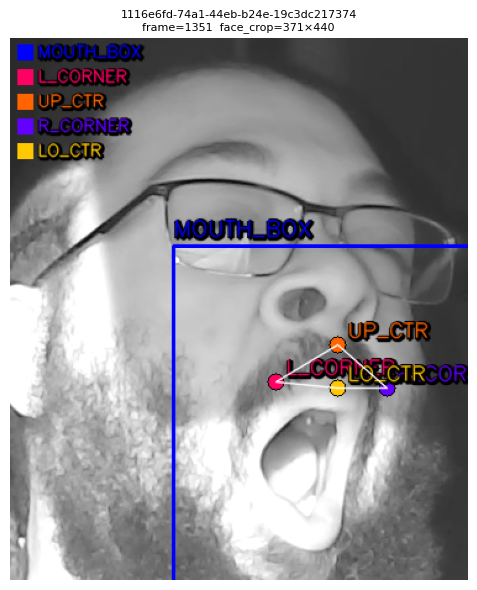

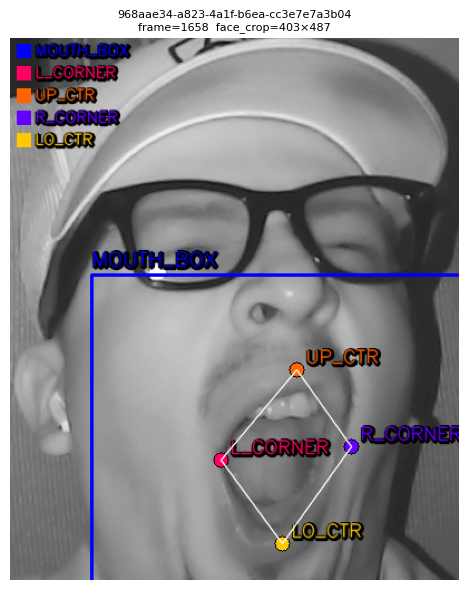

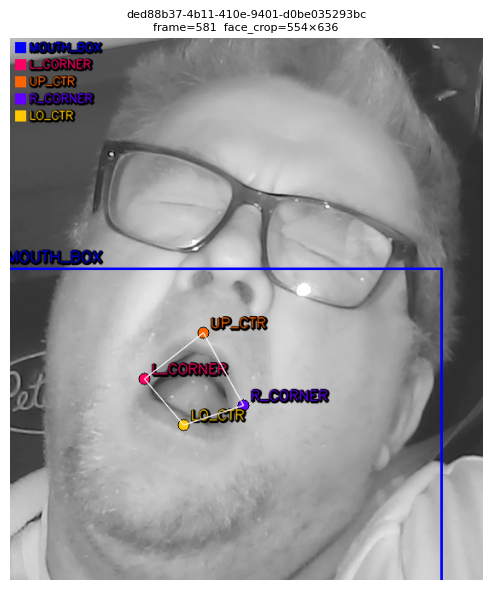

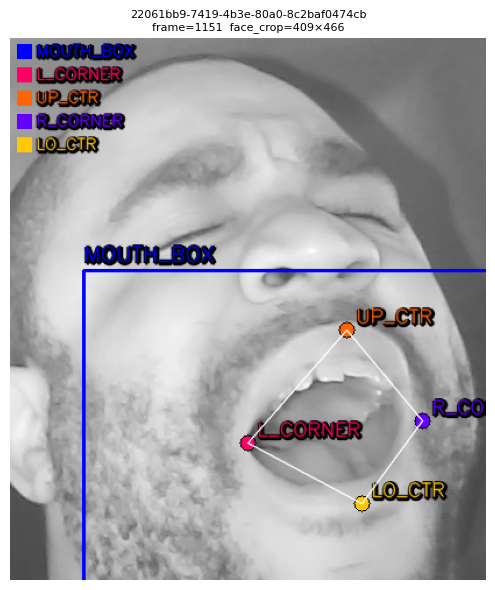

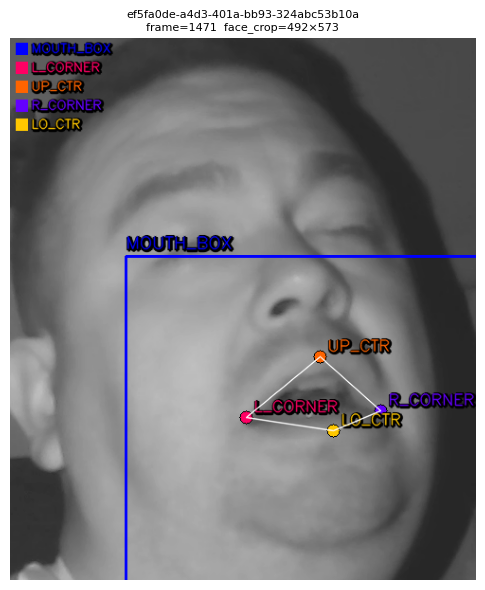

In [1]:
import os
import csv
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

# ── PATHS ─────────────────────────────────────────────────
CSV_PATH = "/inwdata2a/sudhanshu/mouth_keypoints/final_split/test.csv"

# ── CONTROL ───────────────────────────────────────────────
NUM_SAMPLES = 5
RANDOM_SEED = None   # set to int (e.g., 42) for reproducibility

# ── HELPERS ───────────────────────────────────────────────
def parse_box(s):
    return tuple(int(v) for v in s.split(","))

def parse_kps(s):
    return [tuple(float(v) for v in pair.split(",")) for pair in s.split(";")]

def draw_box(img, box, color, text):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, text, (x1 + 1, max(y1 - 7, 14)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(img, text, (x1,     max(y1 - 8, 13)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color,     1, cv2.LINE_AA)

def draw_kp(img, x, y, color, text, radius=7):
    cv2.circle(img, (int(x), int(y)), radius, color,     -1)
    cv2.circle(img, (int(x), int(y)), radius, (0, 0, 0),  1)
    cv2.putText(img, text, (int(x) + 9, int(y) - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 3, cv2.LINE_AA)
    cv2.putText(img, text, (int(x) + 8, int(y) - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, color,     1, cv2.LINE_AA)

# ── KP META ───────────────────────────────────────────────
KP_META = [
    ("L_CORNER",  (255,   0, 100)),
    ("UP_CTR",    (255, 100,   0)),
    ("R_CORNER",  (100,   0, 255)),
    ("LO_CTR",    (255, 200,   0)),
]

# ── LOAD CSV ──────────────────────────────────────────────
with open(CSV_PATH, 'r') as f:
    reader = csv.DictReader(f)
    rows   = list(reader)

# ── RANDOM SAMPLING ───────────────────────────────────────
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

rows = random.sample(rows, min(NUM_SAMPLES, len(rows)))

# ── MAIN LOOP ─────────────────────────────────────────────
for row in rows:
    video_id   = row["video_id"]
    frame_key  = row["frame_key"]
    img_path   = row["path_to_dataset"]

    face_box   = parse_box(row["face_bbox_dms"])
    mouth_box  = parse_box(row["mouth_bbox_face"])
    kps        = parse_kps(row["landmarks_coordinates_inside_mouth_bbox"])

    img = cv2.imread(img_path)
    if img is None:
        print(f"[SKIP] Missing: {img_path}")
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fx1, fy1, fx2, fy2 = face_box
    face_crop = img_rgb[fy1:fy2, fx1:fx2].copy()

    if face_crop.size == 0:
        print(f"[SKIP] Empty face crop: {video_id}_{frame_key}")
        continue

    fH, fW = face_crop.shape[:2]

    # ── Draw mouth bbox ───────────────────────────────────
    draw_box(face_crop, mouth_box, (0, 0, 255), "MOUTH_BOX")

    # ── Draw keypoints ────────────────────────────────────
    for (x, y), (kp_name, color) in zip(kps, KP_META):
        draw_kp(face_crop, x, y, color, kp_name)

    # ── Connect keypoints ─────────────────────────────────
    if len(kps) == 4:
        lc, uc, rc, loc = [(int(x), int(y)) for x, y in kps]
        cv2.line(face_crop, lc, uc,  (255, 255, 255), 1, cv2.LINE_AA)
        cv2.line(face_crop, uc, rc,  (255, 255, 255), 1, cv2.LINE_AA)
        cv2.line(face_crop, lc, loc, (255, 255, 255), 1, cv2.LINE_AA)
        cv2.line(face_crop, loc, rc, (255, 255, 255), 1, cv2.LINE_AA)

    # ── Legend ────────────────────────────────────────────
    legend_items = [
        ("MOUTH_BOX", (0,   0,   255)),
        ("L_CORNER",  (255, 0,   100)),
        ("UP_CTR",    (255, 100,   0)),
        ("R_CORNER",  (100, 0,   255)),
        ("LO_CTR",    (255, 200,   0)),
    ]

    lh, lx, ly = 20, 6, 6
    for i, (txt, col) in enumerate(legend_items):
        yp = ly + i * lh
        cv2.rectangle(face_crop, (lx, yp), (lx+12, yp+12), col, -1)
        cv2.putText(face_crop, txt, (lx+17, yp+11),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 0, 0), 3, cv2.LINE_AA)
        cv2.putText(face_crop, txt, (lx+16, yp+10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, col,       1, cv2.LINE_AA)

    # ── Show ──────────────────────────────────────────────
    plt.figure(figsize=(6, 6))
    plt.imshow(face_crop)
    plt.title(f"{video_id}\nframe={frame_key}  face_crop={fW}×{fH}", fontsize=8)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

## Mediapipe Not working

I0000 00:00:1775205383.413901 1629046 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775205383.464489 1629123 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 570.172.08), renderer: Tesla T4/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775205383.470023 1629111 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775205383.495880 1629115 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/inwdata/x/miniconda/envs/sudhanshu_env/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. P

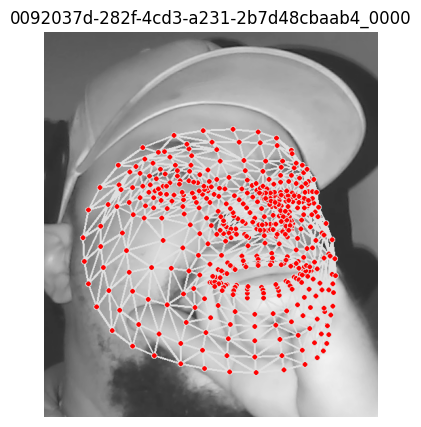

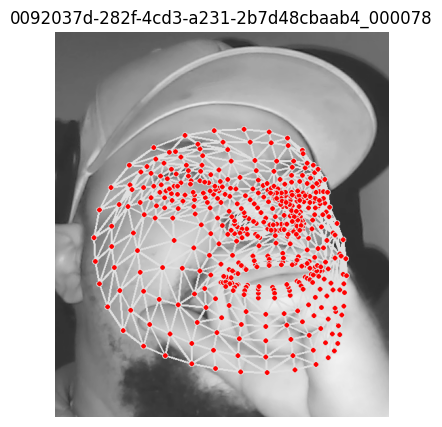

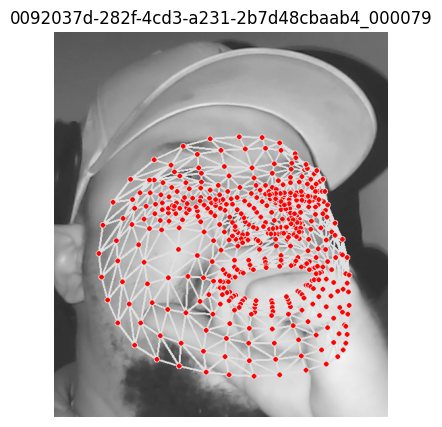

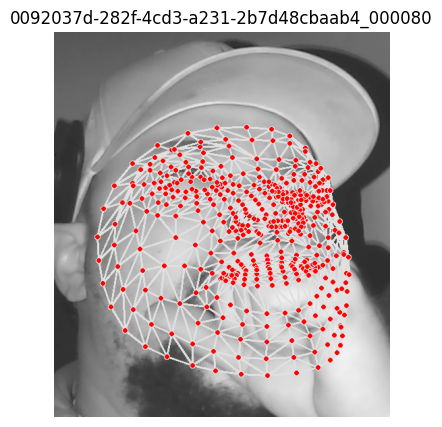

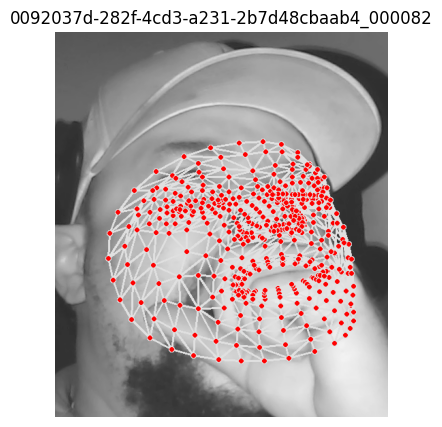

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

# Paths
IMG_DIR = "/inwdata2a/sudhanshu/mouth_keypoints/mouth_frames_dms"
LBL_DIR = "/inwdata2a/sudhanshu/mouth_keypoints/frame_labels/all_frames"

# ---- CONTROL ----
NUM_SAMPLES = 5
DRAW_ON_FULL_IMAGE = False   # True → project back, False → show only face crop

# ---------- MediaPipe Setup ----------
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True,
                                  max_num_faces=1,
                                  refine_landmarks=True)

mp_drawing = mp.solutions.drawing_utils


# ---------- Helpers ----------

def xywh_to_xyxy(label):
    xc, yc, w, h = label
    return np.array([
        xc - w / 2.0,
        yc - h / 2.0,
        xc + w / 2.0,
        yc + h / 2.0
    ])


def unnormalize(box, img_w, img_h):
    x1, y1, x2, y2 = box
    return np.array([
        x1 * img_w,
        y1 * img_h,
        x2 * img_w,
        y2 * img_h
    ])


def draw_box(img, box, color, text):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, text, (x1, y1 - 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return img


# ---------- Main ----------

def visualize_with_mediapipe(num_samples):
    label_files = sorted(os.listdir(LBL_DIR))[:num_samples]

    for lbl_file in label_files:
        name = lbl_file.replace(".txt", "")

        img_path = os.path.join(IMG_DIR, name + ".png")
        lbl_path = os.path.join(LBL_DIR, lbl_file)

        img = cv2.imread(img_path)
        if img is None:
            print(f"❌ Missing image: {img_path}")
            continue

        h, w = img.shape[:2]

        with open(lbl_path, 'r') as f:
            label = list(map(float, f.readline().strip().split()))

        # ---- Face box ----
        face_box = unnormalize(xywh_to_xyxy(label[1:5]), w, h)
        x1, y1, x2, y2 = map(int, face_box)

        # Clamp (important)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)

        face_crop = img[y1:y2, x1:x2].copy()

        if face_crop.size == 0:
            print(f"❌ Empty crop: {name}")
            continue

        # ---- MediaPipe ----
        rgb_crop = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_crop)

        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:

                if DRAW_ON_FULL_IMAGE:
                    # Project landmarks back to original image
                    for lm in face_landmarks.landmark:
                        px = int(lm.x * (x2 - x1)) + x1
                        py = int(lm.y * (y2 - y1)) + y1
                        cv2.circle(img, (px, py), 1, (0, 255, 255), -1)
                else:
                    # Draw directly on crop
                    mp_drawing.draw_landmarks(
                        face_crop,
                        face_landmarks,
                        mp_face_mesh.FACEMESH_TESSELATION
                    )

        # ---- Draw face bbox ----
        img = draw_box(img, face_box, (0, 255, 0), "FACE")

        # ---- Visualization ----
        if DRAW_ON_FULL_IMAGE:
            show_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        else:
            show_img = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6, 5))
        plt.imshow(show_img)
        plt.title(name)
        plt.axis("off")
        plt.show()


# ---------- Run ----------
visualize_with_mediapipe(NUM_SAMPLES)

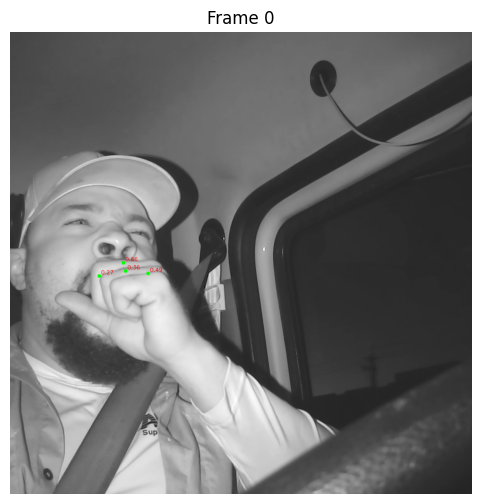

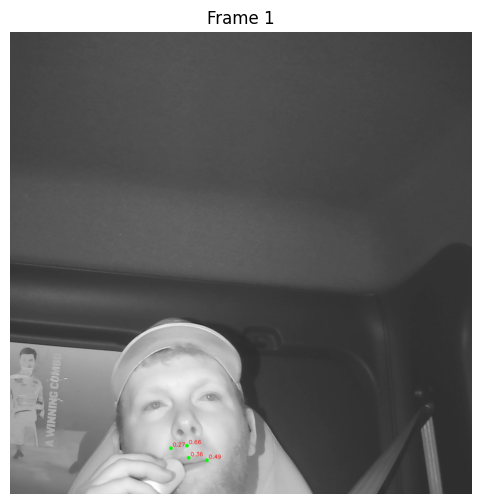

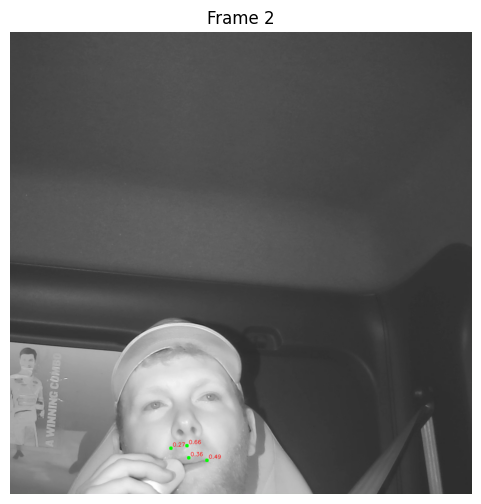

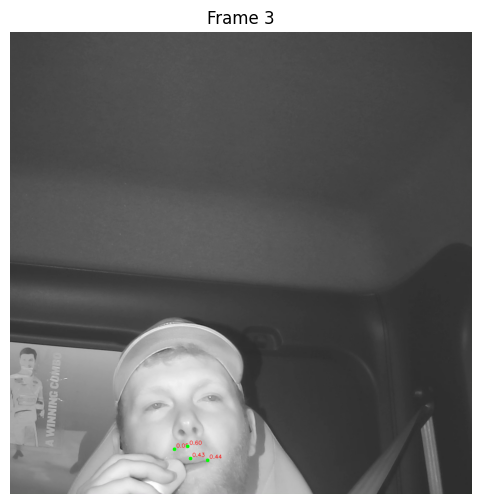

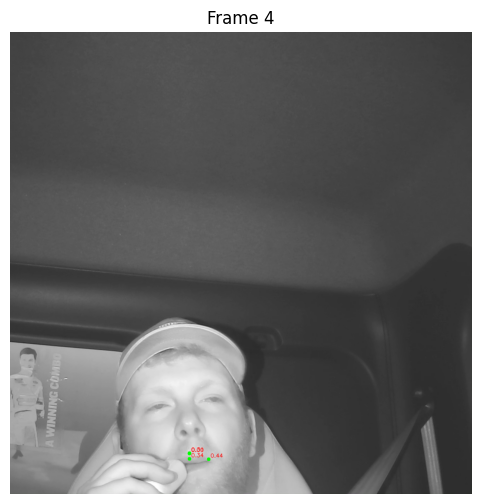

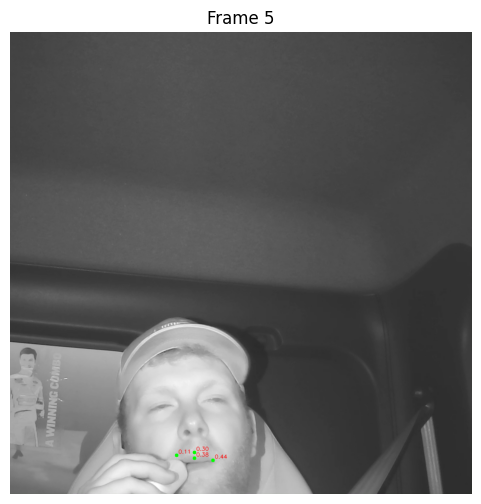

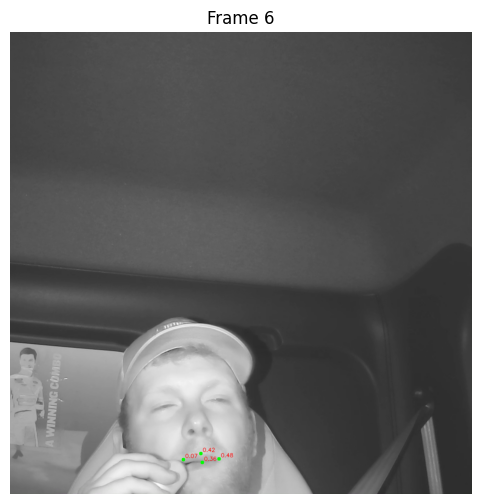

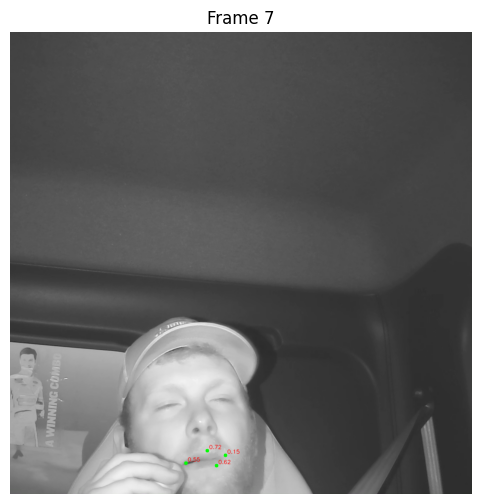

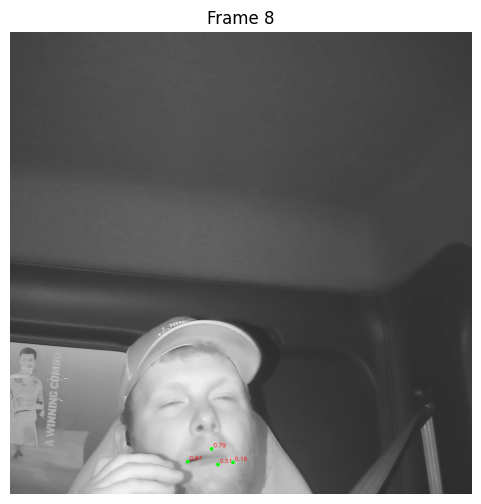

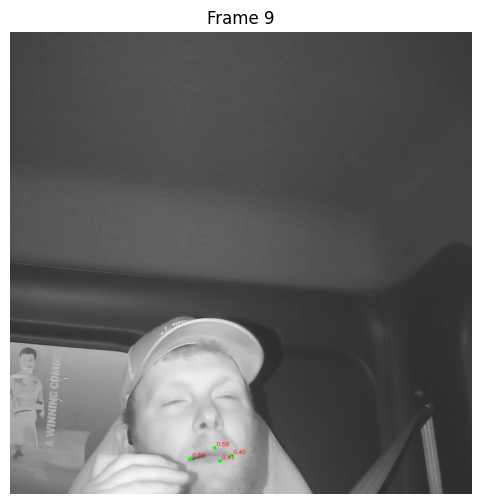

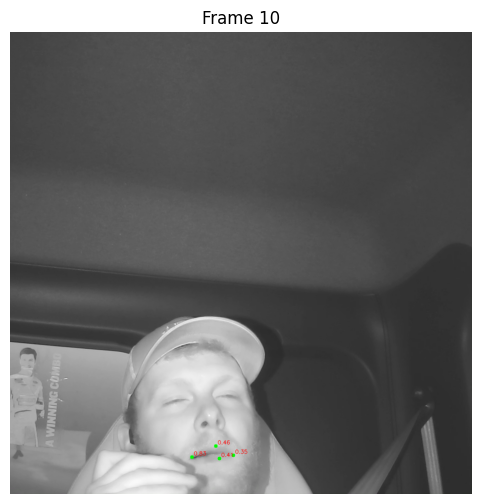

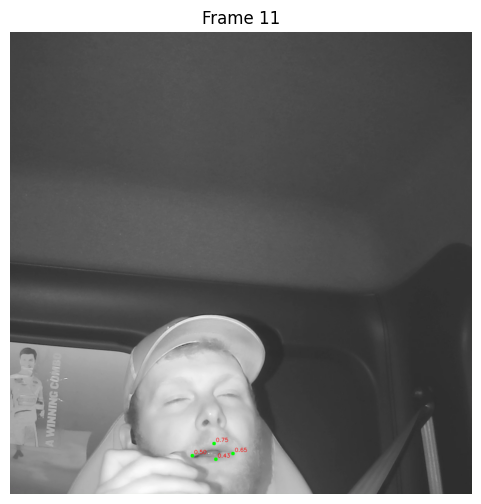

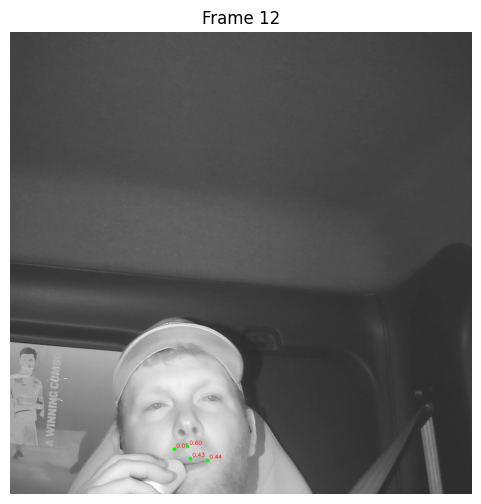

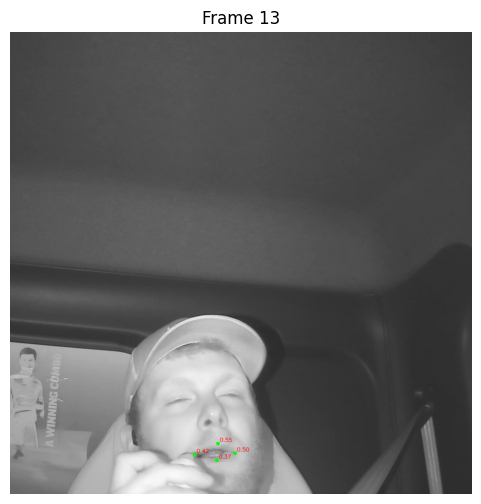

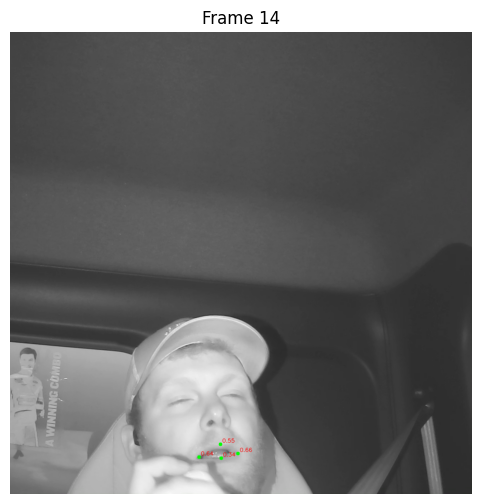

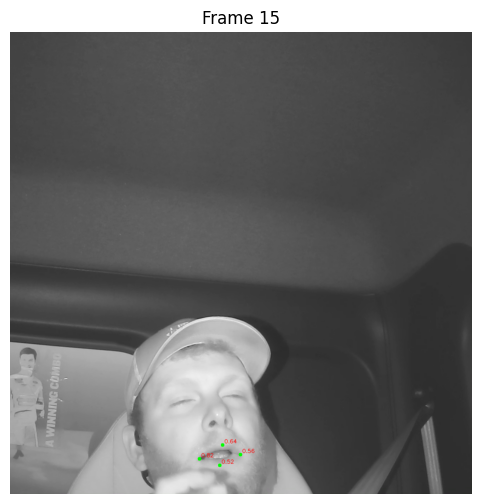

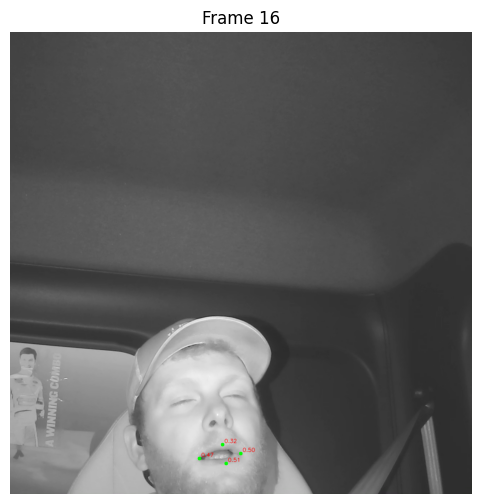

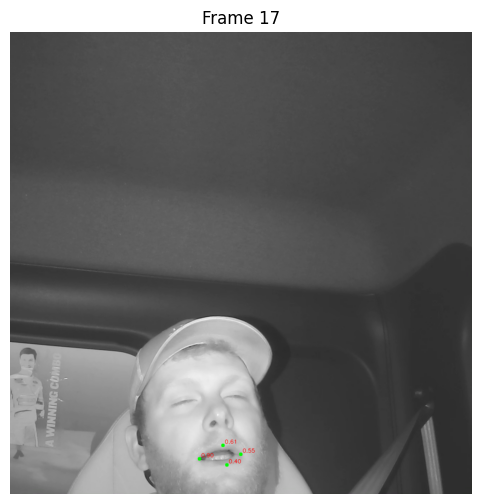

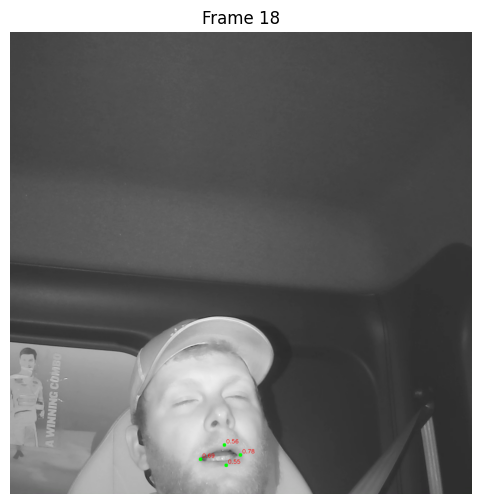

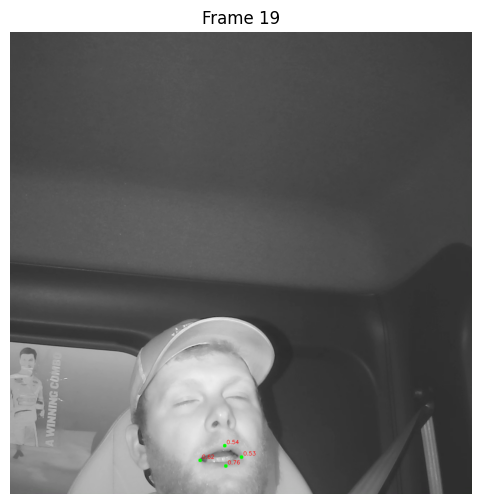

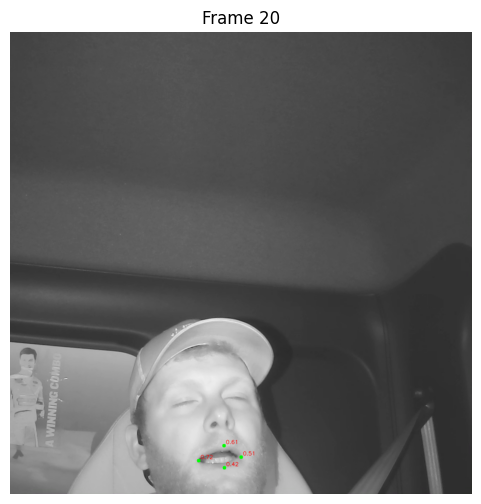

In [2]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load CSV
csv_path = "/inwdata2a/sudhanshu/mouth_keypoints/outputs_landmarks_unet_op_temp_2/per_sample_results_dms.csv"  # update path
df = pd.read_csv(csv_path)

# Function to parse landmarks
def parse_landmarks(landmark_str):
    coords = list(map(float, landmark_str.split(",")))
    return np.array(coords).reshape(-1, 2)  # shape (4,2)

# Iterate through rows
for idx, row in df.iterrows():
    img_path = row["path_dms_frames"]
    
    # Read image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Failed to load: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Parse landmarks
    landmarks = parse_landmarks(row["mouth_landmarks"])
    
    # Get confidences
    confs = [
        row["conf_pt0"],
        row["conf_pt1"],
        row["conf_pt2"],
        row["conf_pt3"]
    ]

    # Draw points + confidence
    for (x, y), conf in zip(landmarks, confs):
        x, y = int(x), int(y)
        
        # Draw point
        cv2.circle(img, (x, y), 5, (0, 255, 0), -1)
        
        # Put confidence text
        cv2.putText(
            img,
            f"{conf:.2f}",
            (x + 5, y - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1,
            cv2.LINE_AA
        )

    # Show image
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f"Frame {idx}")
    plt.axis("off")
    plt.show()